In [10]:
import pandas as pd

# Load CSV file
df = pd.read_csv("raman_spectra_dataset.csv")  # Replace with your file name

# Display first 5 rows
print(df.head())


  spectrum_id                                           spectrum  \
0     RS_0000  [0.47585903 0.47399301 0.47396588 ... 0.189626...   
1     RS_0001  [0.         0.00056019 0.001365   ... 0.037928...   
2     RS_0002  [0.02674333 0.02673678 0.02623422 ... 0.630236...   
3     RS_0003  [0.08308331 0.08141413 0.08174349 ... 0.001559...   
4     RS_0004  [0.00000000e+00 4.40434762e-05 6.76274592e-04 ...   

         category                          wavenumbers         snr  \
0  pharmaceutical  [ 100  102  104 ... 3194 3196 3198]  125.186626   
1  pharmaceutical  [ 100  102  104 ... 3194 3196 3198]  130.654018   
2  pharmaceutical  [ 100  102  104 ... 3194 3196 3198]  135.755062   
3  pharmaceutical  [ 100  102  104 ... 3194 3196 3198]  118.526785   
4  pharmaceutical  [ 100  102  104 ... 3194 3196 3198]   89.581238   

   resolution                                       artifacts  
0           2  {'cosmic_spike': False, 'fluorescence': False}  
1           2   {'cosmic_spike': False, 'f

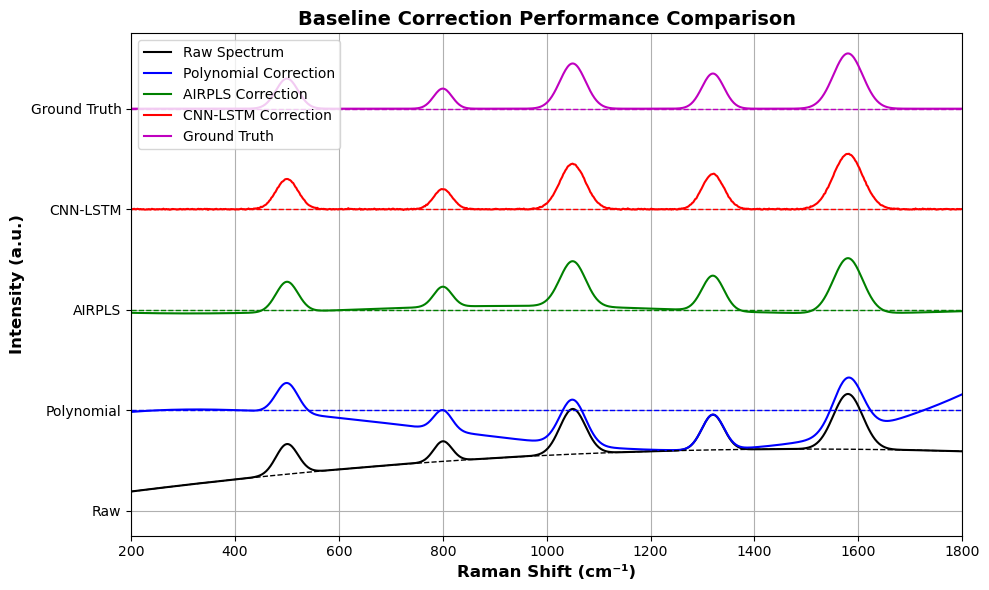

In [13]:
# Convert MATLAB Raman spectrum simulation and visualization into Python using matplotlib and numpy

import numpy as np
import matplotlib.pyplot as plt

# -------------------------- Figure 2: Baseline Correction Comparison --------------------------
# Sample wavenumbers
wavenumbers = np.arange(200, 1802, 2)

# True baseline (for reference)
true_baseline = 0.2 + 0.003 * wavenumbers - 1e-6 * wavenumbers ** 2

# Add characteristic Raman peaks
peak_positions = [500, 800, 1050, 1320, 1580]
peak_intensities = [1.2, 0.8, 1.8, 1.4, 2.2]
peak_widths = [30, 25, 35, 30, 40]

# Construct clean Raman spectrum
clean_spectrum = np.zeros_like(wavenumbers, dtype=float)
for pos, inten, width in zip(peak_positions, peak_intensities, peak_widths):
    clean_spectrum += inten * np.exp(-((wavenumbers - pos) / width) ** 2)

# Raw spectrum with baseline
raw_spectrum = clean_spectrum + true_baseline

# Polynomial baseline estimation (simulate non-peak regions)
poly_fit_idx = np.r_[0:100, 650:750, -100:]
poly_coeffs = np.polyfit(wavenumbers[poly_fit_idx], raw_spectrum[poly_fit_idx], 3)
poly_baseline = np.polyval(poly_coeffs, wavenumbers)
poly_corrected = raw_spectrum - poly_baseline

# AIRPLS baseline approximation (simulated)
airpls_baseline = true_baseline + 0.15 * np.sin(wavenumbers / 200)
airpls_corrected = raw_spectrum - airpls_baseline

# CNN-LSTM corrected (simulated)
np.random.seed(42)
dnn_corrected = clean_spectrum + 0.01 * np.random.randn(len(clean_spectrum))

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(wavenumbers, raw_spectrum, 'k-', linewidth=1.5, label='Raw Spectrum')
plt.plot(wavenumbers, poly_corrected + 4, 'b-', linewidth=1.5, label='Polynomial Correction')
plt.plot(wavenumbers, airpls_corrected + 8, 'g-', linewidth=1.5, label='AIRPLS Correction')
plt.plot(wavenumbers, dnn_corrected + 12, 'r-', linewidth=1.5, label='CNN-LSTM Correction')
plt.plot(wavenumbers, clean_spectrum + 16, 'm-', linewidth=1.5, label='Ground Truth')

# Baseline references
plt.plot(wavenumbers, true_baseline, 'k--', linewidth=1)
plt.plot(wavenumbers, np.zeros_like(wavenumbers) + 4, 'b--', linewidth=1)
plt.plot(wavenumbers, np.zeros_like(wavenumbers) + 8, 'g--', linewidth=1)
plt.plot(wavenumbers, np.zeros_like(wavenumbers) + 12, 'r--', linewidth=1)
plt.plot(wavenumbers, np.zeros_like(wavenumbers) + 16, 'm--', linewidth=1)

# Labels and customizations
plt.xlabel('Raman Shift (cm⁻¹)', fontsize=12, fontweight='bold')
plt.ylabel('Intensity (a.u.)', fontsize=12, fontweight='bold')
plt.title('Baseline Correction Performance Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True)
plt.xlim(wavenumbers[0], wavenumbers[-1])
plt.ylim(-1, 19)
plt.yticks([0, 4, 8, 12, 16], ['Raw', 'Polynomial', 'AIRPLS', 'CNN-LSTM', 'Ground Truth'])
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


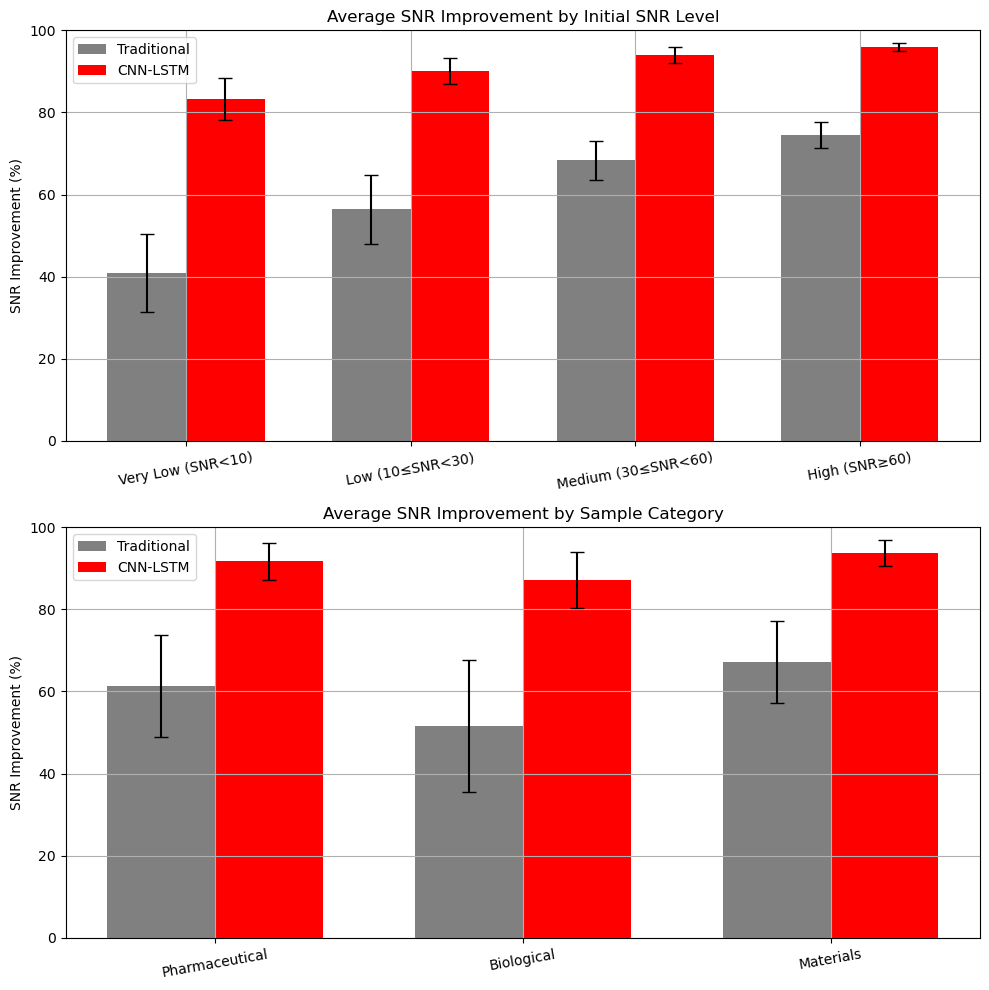

In [14]:
# -------------------------- Figure 3: SNR Improvement Analysis --------------------------
import matplotlib.pyplot as plt
import numpy as np

# Define SNR levels and categories
snr_levels = ['Very Low (SNR<10)', 'Low (10≤SNR<30)', 'Medium (30≤SNR<60)', 'High (SNR≥60)']
categories = ['Pharmaceutical', 'Biological', 'Materials']

# Data
traditional_methods = np.array([
    [42.3, 58.7, 69.5, 74.8],
    [28.6, 45.2, 62.1, 70.6],
    [51.8, 65.3, 73.4, 78.2]
])
cnn_lstm_method = np.array([
    [84.6, 91.3, 94.7, 96.2],
    [76.5, 85.9, 91.4, 94.5],
    [88.7, 93.2, 95.8, 97.1]
])

# Subplot 1: By SNR Level
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

x = np.arange(len(snr_levels))
bar_width = 0.35

# Mean and std
y_trad = traditional_methods.mean(axis=0)
y_cnn = cnn_lstm_method.mean(axis=0)
err_trad = traditional_methods.std(axis=0)
err_cnn = cnn_lstm_method.std(axis=0)

# Bar plot
axs[0].bar(x - bar_width/2, y_trad, bar_width, yerr=err_trad, capsize=5, label='Traditional', color='gray')
axs[0].bar(x + bar_width/2, y_cnn, bar_width, yerr=err_cnn, capsize=5, label='CNN-LSTM', color='red')

axs[0].set_xticks(x)
axs[0].set_xticklabels(snr_levels, rotation=10)
axs[0].set_ylabel('SNR Improvement (%)')
axs[0].set_title('Average SNR Improvement by Initial SNR Level')
axs[0].legend()
axs[0].grid(True)
axs[0].set_ylim([0, 100])

# Subplot 2: By Category
x = np.arange(len(categories))
y_trad_cat = traditional_methods.mean(axis=1)
y_cnn_cat = cnn_lstm_method.mean(axis=1)
err_trad_cat = traditional_methods.std(axis=1)
err_cnn_cat = cnn_lstm_method.std(axis=1)

axs[1].bar(x - bar_width/2, y_trad_cat, bar_width, yerr=err_trad_cat, capsize=5, label='Traditional', color='gray')
axs[1].bar(x + bar_width/2, y_cnn_cat, bar_width, yerr=err_cnn_cat, capsize=5, label='CNN-LSTM', color='red')

axs[1].set_xticks(x)
axs[1].set_xticklabels(categories, rotation=10)
axs[1].set_ylabel('SNR Improvement (%)')
axs[1].set_title('Average SNR Improvement by Sample Category')
axs[1].legend()
axs[1].grid(True)
axs[1].set_ylim([0, 100])

plt.tight_layout()
plt.show()


In [15]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')


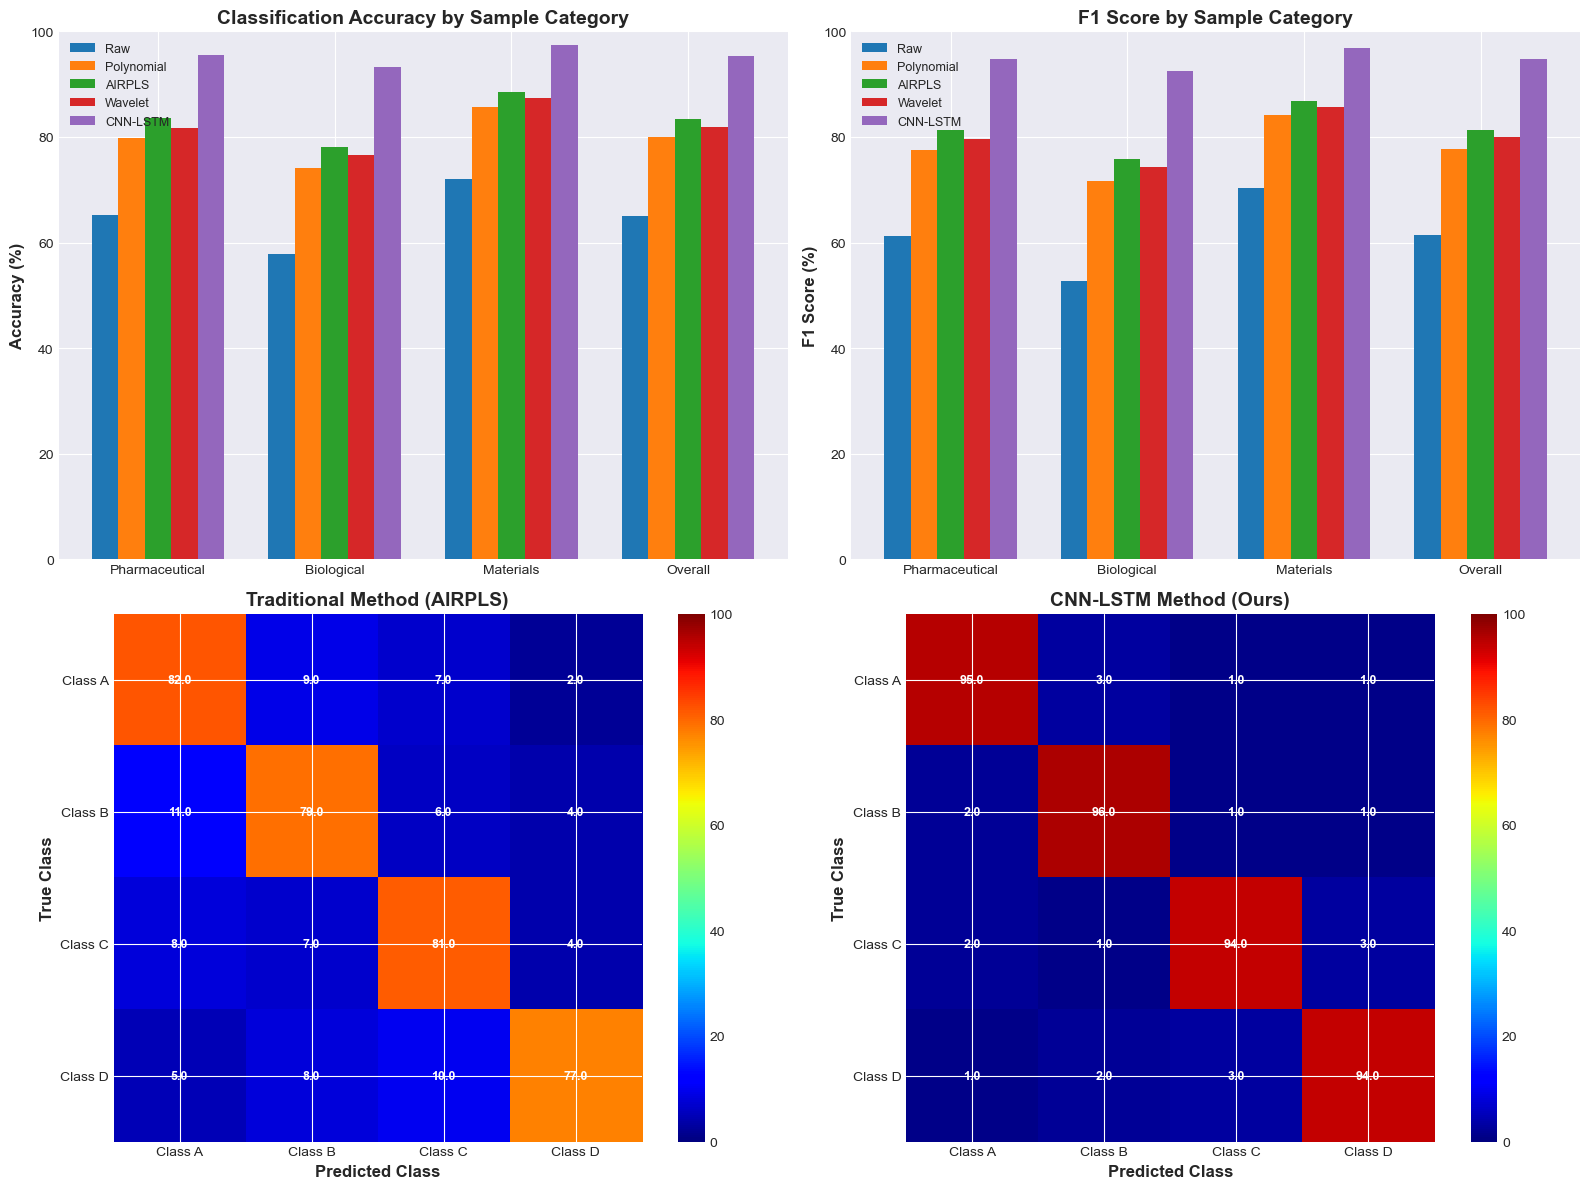

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Data Setup
categories = ['Pharmaceutical', 'Biological', 'Materials', 'Overall']
methods = ['Raw', 'Polynomial', 'AIRPLS', 'Wavelet', 'CNN-LSTM']

accuracies = np.array([
    [65.3, 79.8, 83.5, 81.7, 95.6],
    [57.8, 74.2, 78.1, 76.5, 93.2],
    [72.1, 85.6, 88.5, 87.3, 97.4],
    [65.1, 79.9, 83.4, 81.8, 95.4]
])

f1_scores = np.array([
    [61.2, 77.5, 81.3, 79.6, 94.8],
    [52.7, 71.6, 75.9, 74.3, 92.5],
    [70.3, 84.2, 86.9, 85.7, 96.8],
    [61.4, 77.8, 81.4, 79.9, 94.7]
])

# Confusion Matrices
classes = ['Class A', 'Class B', 'Class C', 'Class D']
traditional_cm = np.array([[82, 9, 7, 2],
                           [11, 79, 6, 4],
                           [8, 7, 81, 4],
                           [5, 8, 10, 77]])

cnn_lstm_cm = np.array([[95, 3, 1, 1],
                        [2, 96, 1, 1],
                        [2, 1, 94, 3],
                        [1, 2, 3, 94]])

# Normalize confusion matrices to percentages
traditional_cm_norm = traditional_cm / traditional_cm.sum(axis=1, keepdims=True) * 100
cnn_lstm_cm_norm = cnn_lstm_cm / cnn_lstm_cm.sum(axis=1, keepdims=True) * 100

# Plotting 2x2 Subplots
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# --- 1️⃣ Classification Accuracy ---
x = np.arange(len(categories))
bar_width = 0.15

for i in range(len(methods)):
    axs[0, 0].bar(x + i*bar_width, accuracies[:, i], width=bar_width, label=methods[i])

axs[0, 0].set_title('Classification Accuracy by Sample Category', fontsize=14, fontweight='bold')
axs[0, 0].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axs[0, 0].set_xticks(x + bar_width*2)
axs[0, 0].set_xticklabels(categories)
axs[0, 0].set_ylim(0, 100)
axs[0, 0].legend(fontsize=9)

# --- 2️⃣ F1 Score ---
for i in range(len(methods)):
    axs[0, 1].bar(x + i*bar_width, f1_scores[:, i], width=bar_width, label=methods[i])

axs[0, 1].set_title('F1 Score by Sample Category', fontsize=14, fontweight='bold')
axs[0, 1].set_ylabel('F1 Score (%)', fontsize=12, fontweight='bold')
axs[0, 1].set_xticks(x + bar_width*2)
axs[0, 1].set_xticklabels(categories)
axs[0, 1].set_ylim(0, 100)
axs[0, 1].legend(fontsize=9)

# --- 3️⃣ Traditional Confusion Matrix ---
im1 = axs[1, 0].imshow(traditional_cm_norm, cmap='jet', vmin=0, vmax=100)
axs[1, 0].set_title('Traditional Method (AIRPLS)', fontsize=14, fontweight='bold')
axs[1, 0].set_xticks(range(len(classes)))
axs[1, 0].set_yticks(range(len(classes)))
axs[1, 0].set_xticklabels(classes)
axs[1, 0].set_yticklabels(classes)
axs[1, 0].set_xlabel('Predicted Class', fontsize=12, fontweight='bold')
axs[1, 0].set_ylabel('True Class', fontsize=12, fontweight='bold')
fig.colorbar(im1, ax=axs[1, 0])

for i in range(len(classes)):
    for j in range(len(classes)):
        axs[1, 0].text(j, i, f"{traditional_cm_norm[i, j]:.1f}", 
                       ha='center', va='center', color='white', fontsize=9, fontweight='bold')

# --- 4️⃣ CNN-LSTM Confusion Matrix ---
im2 = axs[1, 1].imshow(cnn_lstm_cm_norm, cmap='jet', vmin=0, vmax=100)
axs[1, 1].set_title('CNN-LSTM Method (Ours)', fontsize=14, fontweight='bold')
axs[1, 1].set_xticks(range(len(classes)))
axs[1, 1].set_yticks(range(len(classes)))
axs[1, 1].set_xticklabels(classes)
axs[1, 1].set_yticklabels(classes)
axs[1, 1].set_xlabel('Predicted Class', fontsize=12, fontweight='bold')
axs[1, 1].set_ylabel('True Class', fontsize=12, fontweight='bold')
fig.colorbar(im2, ax=axs[1, 1])

for i in range(len(classes)):
    for j in range(len(classes)):
        axs[1, 1].text(j, i, f"{cnn_lstm_cm_norm[i, j]:.1f}", 
                       ha='center', va='center', color='white', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


C:\Users\samra\AppData\Local\Temp\ipykernel_5464\91876445.py:81: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


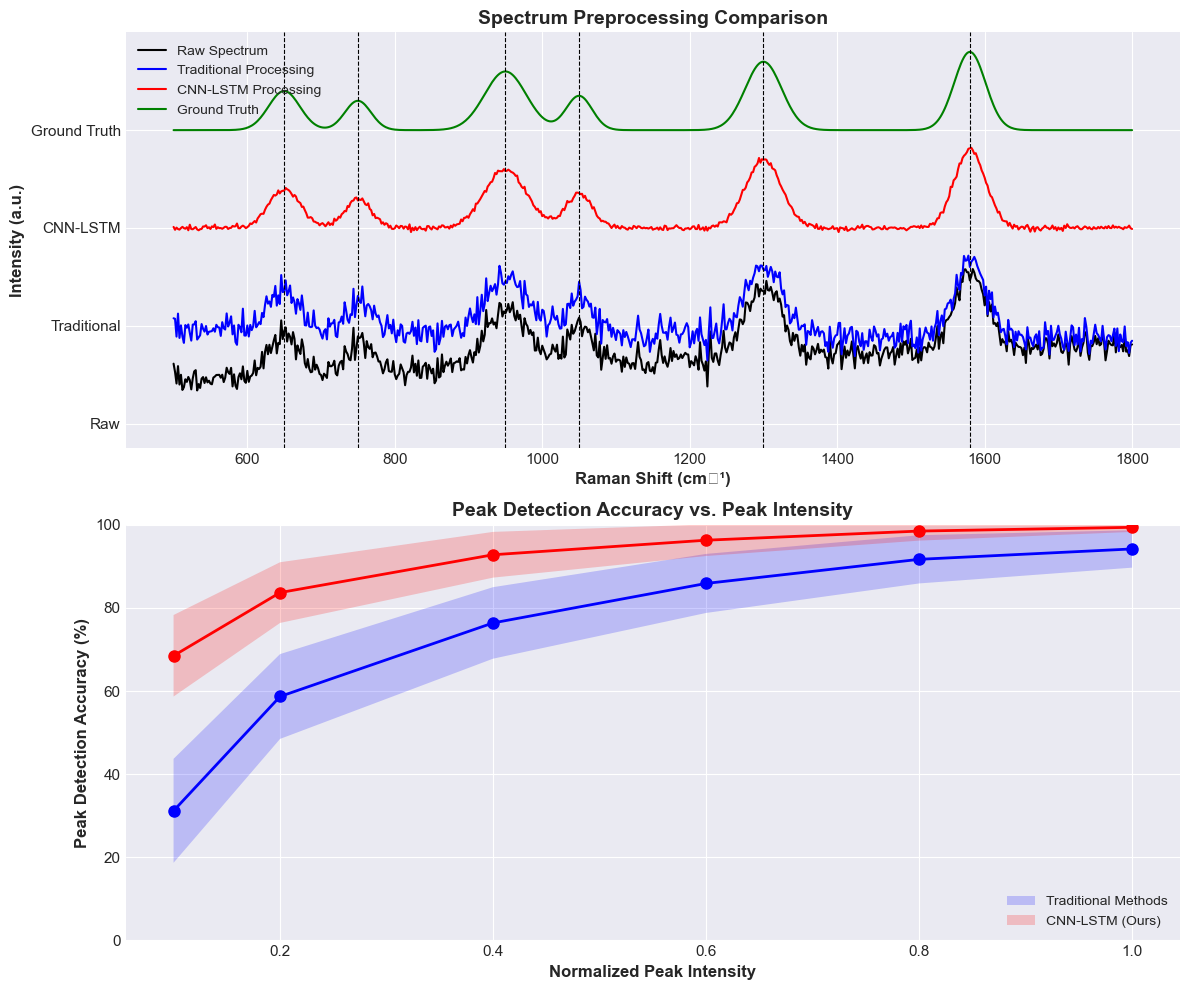

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------- Spectrum Preprocessing Comparison -------------------
wavenumbers = np.arange(500, 1802, 2)

# Generate synthetic clean spectrum
clean_spectrum = np.zeros_like(wavenumbers, dtype=float)
peak_positions = [650, 750, 950, 1050, 1300, 1580]
peak_intensities = [0.8, 0.6, 1.2, 0.7, 1.4, 1.6]
peak_widths = [30, 25, 40, 25, 35, 30]

for pos, inten, width in zip(peak_positions, peak_intensities, peak_widths):
    clean_spectrum += inten * np.exp(-((wavenumbers - pos) / width)**2)

# Add baseline and noise
baseline = 0.5 + 0.0008 * wavenumbers - 1e-7 * wavenumbers**2
noise_level = 0.15
noisy_spectrum = clean_spectrum + baseline + noise_level * np.random.randn(len(wavenumbers))

# Traditional preprocessing
traditional_baseline = 0.45 + 0.001 * wavenumbers - 1.2e-7 * wavenumbers**2
traditional_result = noisy_spectrum - traditional_baseline
traditional_result += 0.08 * np.random.randn(len(traditional_result)) - 0.03

# CNN-LSTM simulated result
cnn_lstm_result = clean_spectrum + 0.03 * np.random.randn(len(clean_spectrum))

# Plotting
fig, axs = plt.subplots(2, 1, figsize=(12, 10))

# --- Subplot 1: Spectrum Comparison ---
axs[0].plot(wavenumbers, noisy_spectrum, 'k-', label='Raw Spectrum')
axs[0].plot(wavenumbers, traditional_result + 2, 'b-', label='Traditional Processing')
axs[0].plot(wavenumbers, cnn_lstm_result + 4, 'r-', label='CNN-LSTM Processing')
axs[0].plot(wavenumbers, clean_spectrum + 6, 'g-', label='Ground Truth')

# Annotate true peaks
for pos in peak_positions:
    axs[0].axvline(x=pos, color='k', linestyle='--', linewidth=0.8)

axs[0].set_title('Spectrum Preprocessing Comparison', fontsize=14, fontweight='bold')
axs[0].set_xlabel('Raman Shift (cm⁻¹)', fontsize=12, fontweight='bold')
axs[0].set_ylabel('Intensity (a.u.)', fontsize=12, fontweight='bold')
axs[0].set_yticks([0, 2, 4, 6])
axs[0].set_yticklabels(['Raw', 'Traditional', 'CNN-LSTM', 'Ground Truth'])
axs[0].grid(True)
axs[0].legend(loc='upper left')
axs[0].set_ylim([-0.5, 8])
axs[0].tick_params(labelsize=11)

# ------------------- Peak Detection Accuracy -------------------
peak_intensities_norm = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
traditional_accuracy = np.array([31.2, 58.7, 76.4, 85.9, 91.7, 94.2])
cnn_lstm_accuracy = np.array([68.5, 83.7, 92.8, 96.3, 98.5, 99.4])

traditional_std = np.array([12.5, 10.2, 8.6, 7.1, 5.8, 4.5])
cnn_lstm_std = np.array([9.8, 7.3, 5.5, 3.8, 2.3, 1.1])

# Error fill for Traditional
x_fill = peak_intensities_norm + peak_intensities_norm[::-1]
y_fill_trad = list(traditional_accuracy + traditional_std) + list((traditional_accuracy - traditional_std)[::-1])
axs[1].fill(x_fill, y_fill_trad, 'b', alpha=0.2)

# Error fill for CNN-LSTM
y_fill_cnn = list(cnn_lstm_accuracy + cnn_lstm_std) + list((cnn_lstm_accuracy - cnn_lstm_std)[::-1])
axs[1].fill(x_fill, y_fill_cnn, 'r', alpha=0.2)

# Plot accuracy lines
axs[1].plot(peak_intensities_norm, traditional_accuracy, 'bo-', linewidth=2, markersize=8, markerfacecolor='b')
axs[1].plot(peak_intensities_norm, cnn_lstm_accuracy, 'ro-', linewidth=2, markersize=8, markerfacecolor='r')

axs[1].set_xlabel('Normalized Peak Intensity', fontsize=12, fontweight='bold')
axs[1].set_ylabel('Peak Detection Accuracy (%)', fontsize=12, fontweight='bold')
axs[1].set_title('Peak Detection Accuracy vs. Peak Intensity', fontsize=14, fontweight='bold')
axs[1].legend(['Traditional Methods', 'CNN-LSTM (Ours)'], loc='lower right')
axs[1].grid(True)
axs[1].set_ylim([0, 100])
axs[1].tick_params(labelsize=11)

plt.tight_layout()
plt.show()
